Epoch 10, Loss: 2.2925
Epoch 20, Loss: 2.2721
Epoch 30, Loss: 2.2290
Epoch 40, Loss: 2.1424
Epoch 50, Loss: 1.9915
Epoch 60, Loss: 1.7719
Epoch 70, Loss: 1.5162
Epoch 80, Loss: 1.2821
Epoch 90, Loss: 1.0993
Epoch 100, Loss: 0.9628
Train Accuracy: 0.7839833333333334
Test Accuracy: 0.7879
Min prediction: 0
Max prediction: 9
Any NaNs? False


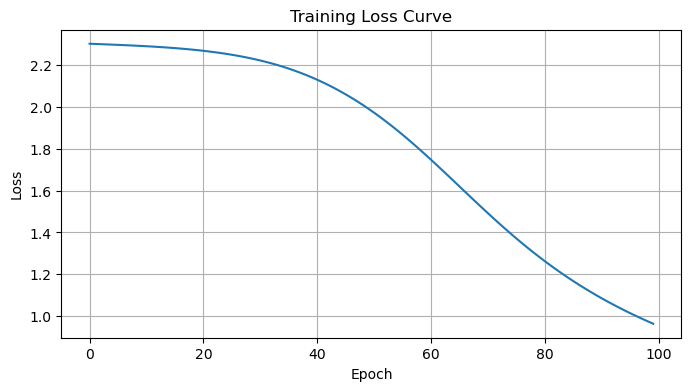

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv(r"C:\Users\user\Downloads\mnist_train.csv", header=None)
test_df = pd.read_csv(r"C:\Users\user\Downloads\mnist_test.csv\mnist_test.csv", header=None)

X_train = train_df.iloc[:, 1:].to_numpy() / 255.0
y_train = train_df.iloc[:, 0].to_numpy()

X_test = test_df.iloc[:, 1:].to_numpy() / 255.0
y_test = test_df.iloc[:, 0].to_numpy()

def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

y_train_oh = one_hot_encode(y_train)
y_test_oh = one_hot_encode(y_test)

input_size = 784
hidden_size = 128
output_size = 10

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def compute_loss(Y_true, Y_pred):
    m = Y_true.shape[0]
    loss = -np.sum(Y_true * np.log(Y_pred + 1e-8)) / m
    return loss

def train(X, Y, epochs=50, lr=0.1):
    global W1, b1, W2, b2
    losses = []

    for epoch in range(epochs):
        Z1 = X.dot(W1) + b1
        A1 = relu(Z1)
        Z2 = A1.dot(W2) + b2
        A2 = softmax(Z2)

        loss = compute_loss(Y, A2)
        losses.append(loss)

        m = Y.shape[0]
        dZ2 = A2 - Y
        dW2 = A1.T.dot(dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2.dot(W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T.dot(dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    return losses

def predict(X):
    Z1 = X.dot(W1) + b1
    A1 = relu(Z1)
    Z2 = A1.dot(W2) + b2
    A2 = softmax(Z2)
    return np.argmax(A2, axis=1)

def accuracy(X, Y_true):
    y_pred = predict(X)
    y_true = np.argmax(Y_true, axis=1)
    return np.mean(y_pred == y_true)

losses = train(X_train, y_train_oh, epochs=100, lr=0.1)

print("Train Accuracy:", accuracy(X_train, y_train_oh))
print("Test Accuracy:", accuracy(X_test, y_test_oh))

y_pred = predict(X_test)

print("Min prediction:", np.min(y_pred))
print("Max prediction:", np.max(y_pred))
print("Any NaNs?", np.isnan(y_pred).any())


plt.figure(figsize=(8, 4))
sns.lineplot(x=np.arange(len(losses)), y=losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()
